# Stochastic GW spectrum from oscillons

Driver notebook for [`bssn/GWSignal.py`](../../bssn/GWSignal.py).

Implements the semi-analytical scheme of Antusch, Cefalà & Orani
([arXiv:1712.03231](https://arxiv.org/abs/1712.03231)) to compute the
stochastic gravitational-wave spectrum $\Omega_{\rm GW}(k)$ produced by
oscillons in our spherical-symmetry simulations, for both GR and
Einstein–scalar–Gauss–Bonnet (EsGB) gravity.

## Outline
1. Setup & path discovery.
2. Load one GR and one EsGB run, extract the parameters that feed the
   GW pipeline: $(A, R, \omega_{\rm source}, H_0)$.
3. **Equation-of-state sanity check.** The GW pipeline assumes
   $w = 0$ (matter domination, see Aurrekoetxea, Clough & Muia 2023 for
   this exact potential). The standalone diagnostic
   `check_equation_of_state` measures $w_{\rm eff}$ from $H(a)$ and warns
   if $|w_{\rm eff}| > 0.05$. Its output is purely informational.
4. Plot the source power spectrum $|\widetilde{\Phi^2}(\omega)|^2$ for both runs.
5. Compute and overlay $\Omega_{\rm GW}(k)$ for GR vs EsGB, with the ratio panel.
6. Fit the power-law $\Omega_{\rm GW} = A_{\rm GW}\,(k/\omega_s)^{n_{\rm GW}}$ and compare to the paper analytic scalings (sweep $w$ explicitly).
7. Apply analytic scaling relations ($\Omega \propto A^4$, $\Delta^2$, $N$).

All heavy lifting is delegated to `GWSignal.py`; this notebook is a
thin orchestration layer and is meant to be edited freely to play with
free parameters ($\Delta$, $N$, comoving volume $V$, etc.).

## 1 — Setup

In [1]:
import os, sys, importlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Project root so we can `from bssn.GWSignal import ...`
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import bssn.GWSignal as gw
importlib.reload(gw)  # pick up the latest edits when re-running
from bssn.GWSignal import (
    OscillonRun,
    Omega_GW,
    check_equation_of_state,
    compute_and_plot,
    compare_runs,
    plot_AGW_nGW_vs_w,
    AGW_of_w,
    nGW_of_w,
    Omega_GW_amplitude_scaling,
    Omega_GW_asymmetry_scaling,
    Omega_GW_N_scaling,
    find_run_dir,
    DEFAULT_DATA_DIR,
    DEFAULT_GR_TAG,
    DEFAULT_ESGB_TAG,
    DEFAULT_DELTA,
)

DATA_DIR = DEFAULT_DATA_DIR
print(f'DATA_DIR = {DATA_DIR}')
print(f'Default GR   tag = {DEFAULT_GR_TAG}')
print(f'Default EsGB tag = {DEFAULT_ESGB_TAG}')

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
Default GR   tag = lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_0
Default EsGB tag = lgb1.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0


## 2 — Load runs and extract parameters

Edit `GR_TAG` / `ESGB_TAG` to compare any other pair of runs.

The pipeline extracts $(A, R, \omega_{\rm source}, H_0)$ from each run.
**The equation of state $w$ is hard-coded to $0$** (matter domination)
in all subsequent GW computations — it is *not* fitted from $H(a)$.
The next cell runs a standalone sanity check on this assumption.

In [2]:
GR_TAG   = DEFAULT_GR_TAG
ESGB_TAG = DEFAULT_ESGB_TAG

STABLE_WINDOW = (2.0, 3.6)   # ln(a/a0) window for parameter extraction

gr_run   = OscillonRun(find_run_dir(GR_TAG,   DATA_DIR), label='GR',   stable_window=STABLE_WINDOW)
esgb_run = OscillonRun(find_run_dir(ESGB_TAG, DATA_DIR), label='EsGB', stable_window=STABLE_WINDOW)

print('--- GR ---')
params_GR = gr_run.extract_all(verbose=True)
print('\n--- EsGB ---')
params_EsGB = esgb_run.extract_all(verbose=True)

--- GR ---
[GR]
  A             = 2.7347e-01
  R             = 9.6595  (1/m)
  omega_source  = 0.0813  (m)
  w             = +0.000   (assumed; not fitted -- see check_equation_of_state)
  H0            = 4.1458e-03  (m)

--- EsGB ---
[EsGB]
  A             = 1.7897e-01
  R             = 11.8739  (1/m)
  omega_source  = 0.0390  (m)
  w             = +0.000   (assumed; not fitted -- see check_equation_of_state)
  H0            = 5.3264e-03  (m)


## 3 — Equation-of-state sanity check

Verify that the matter-domination assumption ($w = 0$) used by `Omega_GW`
is justified for each run. The diagnostic computes
$$
w_{\rm eff} = -1 - \tfrac{2}{3}\,\frac{d \ln H}{d \ln a},
$$
fitted across the stable oscillon window (which spans many oscillation
cycles), and prints a warning if $|w_{\rm eff}| > 0.05$.

This is purely informational: the result is **not** plumbed back into
the GW calculation. If you want to override $w$, pass it explicitly to
`Omega_GW(..., w=w_eff)`.

In [3]:
print('--- GR ---')
eos_GR = check_equation_of_state(gr_run, n_cycles=5, tol=0.05)
print('\n--- EsGB ---')
eos_EsGB = check_equation_of_state(esgb_run, n_cycles=5, tol=0.05)

if eos_GR['warning'] or eos_EsGB['warning']:
    print('\n[Warning] At least one run shows |w_eff| > 0.05.')
    print('          Consider overriding w in Omega_GW for that run.')
else:
    print('\nBoth runs are consistent with matter domination (|w_eff| <= 0.05).')

--- GR ---
[check_equation_of_state] GR
  stable window      = ln a in (2.0, 3.6)
  H0 (start of win.) = 4.1458e-03  m
  d ln H / d ln a    = -1.1758
  w_eff (global fit) = -0.2161   (R^2 = 1.000)
  w_eff (local)      = -0.2175  +/- 0.0022   (387 sliding windows of ~5.0 cycles)

--- EsGB ---
[check_equation_of_state] EsGB
  stable window      = ln a in (2.0, 3.6)
  H0 (start of win.) = 5.3264e-03  m
  d ln H / d ln a    = -1.0201
  w_eff (global fit) = -0.3199   (R^2 = 1.000)
  w_eff (local)      = -0.3216  +/- 0.0024   (404 sliding windows of ~5.0 cycles)

[Warning] At least one run shows |w_eff| > 0.05.
          Consider overriding w in Omega_GW for that run.


## 4 — Source power spectrum $|\widetilde{\Phi^2}(\omega)|^2$

Locates the dominant frequency $\omega_{\rm source}$ (where the GW peak
will sit) and any subdominant harmonics. For our asymmetric inflaton
potential the peak is at $\omega_{\rm osc}$ itself (the paper's symmetric
potential gives a peak at $2\omega_{\rm osc}$).

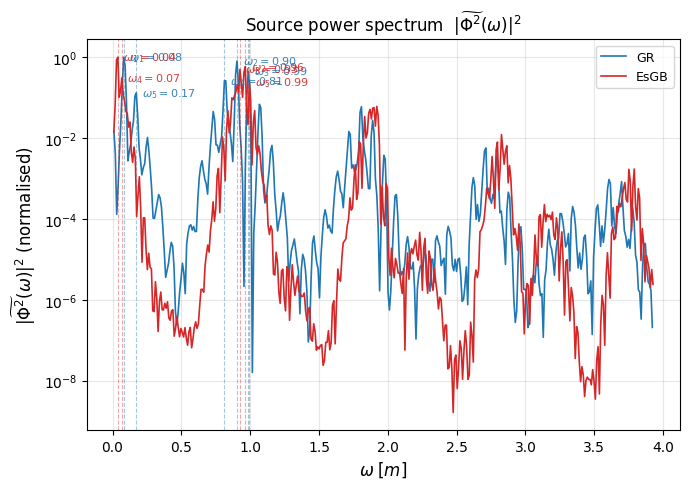

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
gr_run.plot_source_power_spectrum(ax=ax, color='C0')
esgb_run.plot_source_power_spectrum(ax=ax, color='C3')
ax.set_title(r'Source power spectrum  $|\widetilde{\Phi^2}(\omega)|^2$')
fig.tight_layout()
plt.show()

## 5 — $\Omega_{\rm GW}(k)$: GR vs EsGB

Free parameters of the model (paper Sec. 4.2):
* `Delta` — oscillon asymmetry (default 0.3),
* `N` — number of oscillons in the comoving box,
* `V` — comoving volume of the box (default $(100 R)^3$),
* `n_angles`, `n_tau` — numerical resolutions of the $d\Omega$ and $d\tau'$ integrals.

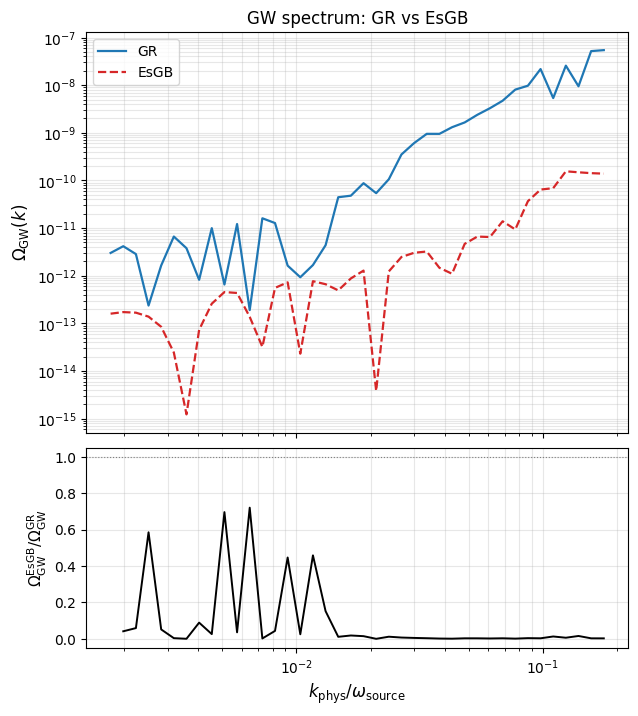


GR   peak: k_phys/omega_s = 0.176, Omega_max = 5.436e-08
EsGB peak: k_phys/omega_s = 0.124, Omega_max = 1.557e-10


In [5]:
Delta    = DEFAULT_DELTA   # oscillon asymmetry
N_OSC    = 1               # number of oscillons in the box
N_ANGLES = 16              # 20-50 is a good range; 16 is fast for sanity check
N_TAU    = 800             # number of conformal-time samples
SEED     = 42              # shared seed -> identical positions/phases for both runs

fig, axes, (res_GR, res_EsGB) = compare_runs(
    gr_run, esgb_run,
    labels=('GR', 'EsGB'),
    Delta=Delta, N=N_OSC, seed=SEED,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()

print(f"\nGR   peak: k_phys/omega_s = {res_GR['peak_k']  /params_GR['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_GR['Omega_GW']):.3e}")
print(f"EsGB peak: k_phys/omega_s = {res_EsGB['peak_k']/params_EsGB['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_EsGB['Omega_GW']):.3e}")

## 6 — Power-law fit $A_{\rm GW}(w)$, $n_{\rm GW}(w)$ vs paper analytics

Since $w$ is hard-coded to $0$ in the GW pipeline, the runs themselves
all sit at the same $w$. To compare with the analytic fits eqs. 4.18–4.21
of the paper we explicitly **sweep** $w$ in `Omega_GW` (this is purely a
theoretical exploration; the physical runs only correspond to the $w=0$
point).

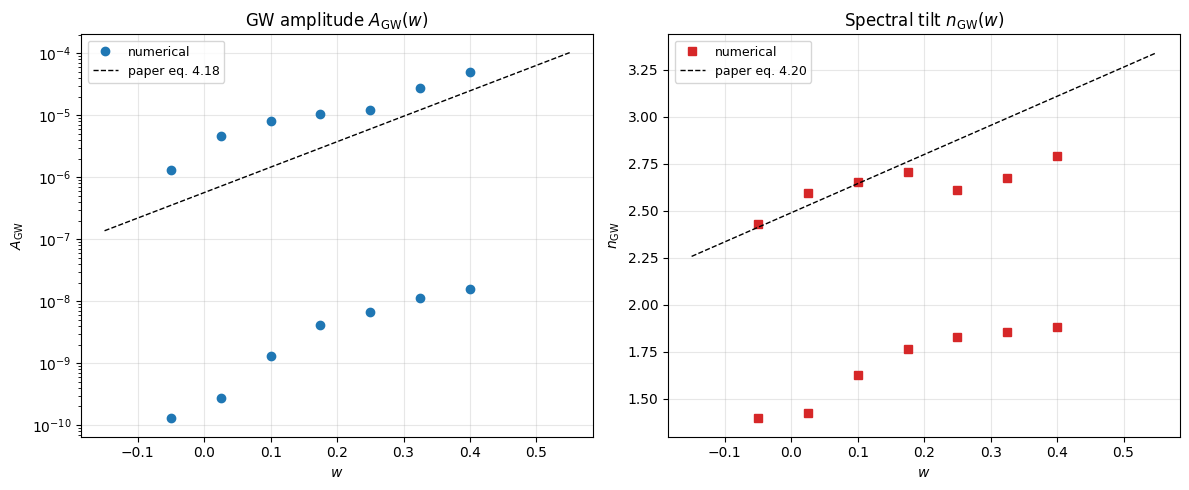

Numerical fits (one per (run, w) pair):
                    GR (w=-0.05): w = -0.050, A_GW = 1.329e-06, n_GW = 2.427
                    GR (w=+0.02): w = +0.025, A_GW = 4.614e-06, n_GW = 2.594
                    GR (w=+0.10): w = +0.100, A_GW = 8.208e-06, n_GW = 2.651
                    GR (w=+0.17): w = +0.175, A_GW = 1.067e-05, n_GW = 2.706
                    GR (w=+0.25): w = +0.250, A_GW = 1.206e-05, n_GW = 2.613
                    GR (w=+0.33): w = +0.325, A_GW = 2.800e-05, n_GW = 2.675
                    GR (w=+0.40): w = +0.400, A_GW = 4.973e-05, n_GW = 2.792
                  EsGB (w=-0.05): w = -0.050, A_GW = 1.282e-10, n_GW = 1.395
                  EsGB (w=+0.02): w = +0.025, A_GW = 2.720e-10, n_GW = 1.425
                  EsGB (w=+0.10): w = +0.100, A_GW = 1.328e-09, n_GW = 1.625
                  EsGB (w=+0.17): w = +0.175, A_GW = 4.194e-09, n_GW = 1.764
                  EsGB (w=+0.25): w = +0.250, A_GW = 6.784e-09, n_GW = 1.829
                  EsGB (w=+0.33): w 

In [6]:
w_sweep = np.linspace(-0.05, 0.40, 7)

fig, axes, summary = plot_AGW_nGW_vs_w(
    [gr_run, esgb_run],
    w_values=w_sweep,
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()

print('Numerical fits (one per (run, w) pair):')
for w_, A_, n_, l_ in zip(summary['w'], summary['A_GW'], summary['n_GW'], summary['labels']):
    print(f'  {l_:>30s}: w = {w_:+.3f}, A_GW = {A_:.3e}, n_GW = {n_:.3f}')

print('\nPaper analytic at w = 0 (the value used by the GW pipeline):')
print(f'  A_GW(w=0) = {AGW_of_w(0.0):.3e}, n_GW(w=0) = {nGW_of_w(0.0):.3f}')

## 7 — Analytic scaling helpers (Sec. 4 of the paper)

Cheap predictions for parameter sweeps without re-running the full integral:
$\Omega_{\rm GW} \propto A^4$, $\Omega_{\rm GW} \propto \Delta^2$,
$\Omega_{\rm GW} \propto N$ (incoherent random phases).

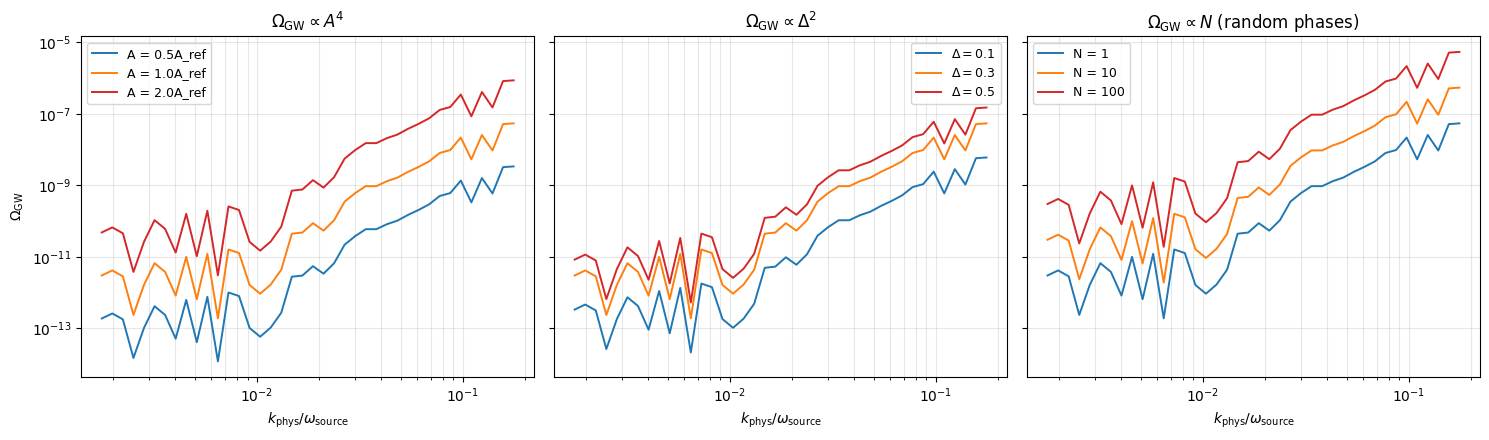

In [7]:
Omega_ref = res_GR['Omega_GW']
k_phys_norm = res_GR['k_phys'] / params_GR['omega_source']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# Amplitude scaling: A -> 0.5 A, A, 2 A
ax = axes[0]
for fac, c in zip([0.5, 1.0, 2.0], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_amplitude_scaling(Omega_ref, fac * params_GR['A'], params_GR['A']),
              color=c, lw=1.4, label=f'A = {fac}A_ref')
ax.set_title(r'$\Omega_{\rm GW} \propto A^4$')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$'); ax.set_ylabel(r'$\Omega_{\rm GW}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# Asymmetry scaling: Delta -> 0.1, 0.3, 0.5
ax = axes[1]
for d, c in zip([0.1, 0.3, 0.5], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_asymmetry_scaling(Omega_ref, d, Delta),
              color=c, lw=1.4, label=fr'$\Delta = {d}$')
ax.set_title(r'$\Omega_{\rm GW} \propto \Delta^2$')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# N scaling: N = 1, 10, 100
ax = axes[2]
for n, c in zip([1, 10, 100], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_N_scaling(Omega_ref, n, N_OSC),
              color=c, lw=1.4, label=f'N = {n}')
ax.set_title(r'$\Omega_{\rm GW} \propto N$ (random phases)')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

fig.tight_layout()
plt.show()

## 8 — Single-run plot (template for any other run)

Use this cell to compute and visualise $\Omega_{\rm GW}(k)$ for any single
run loaded above. Replace `gr_run` with `esgb_run` (or any other
`OscillonRun` instance) as needed.

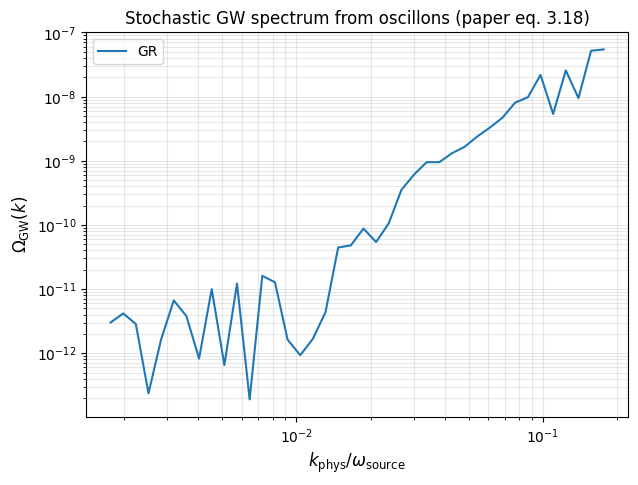

peak  k_phys = 0.0143  (omega_source = 0.0813)
A_GW = 2.375e-06, n_GW = 2.527


In [8]:
ax, res = compute_and_plot(
    gr_run,
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()
print(f"peak  k_phys = {res['peak_k']:.4f}  (omega_source = {params_GR['omega_source']:.4f})")
print(f"A_GW = {res['A_GW']:.3e}, n_GW = {res['n_GW']:.3f}")